# 1st-Order Differential Equations with 1 variable

## Euler's Method

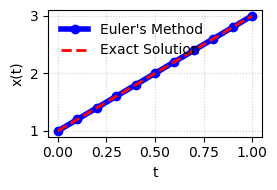

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, t):
    return 2*x - 4*t

t0, tend = 0, 1
x0 = 1
h = 0.1
N = int((tend - t0) / h)

t = np.zeros(N+1)
x = np.zeros(N+1)

t[0], x[0] = t0, x0

for i in range(N):
    t[i+1] = t[i] + h
    x[i+1] = x[i] + h * f(x[i], t[i])

t_exact = np.linspace(t0, tend, 200)
x_exact = 2 * t_exact + 1                 

plt.figure(figsize=(3, 2))
plt.plot(t, x, 'bo-', label="Euler's Method", linewidth=4)
plt.plot(t_exact, x_exact, 'r--', label="Exact Solution", linewidth=2)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(frameon=False)
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 2nd-Order Runge-Kutta Method

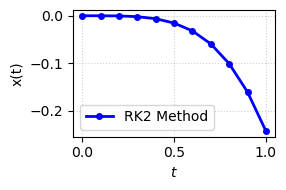

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, t):
    return x ** 2 - t ** 3

h = 0.1
t0, tend = 0, 1
x0 = 0
N = int((tend-t0)/h)
x = np.zeros(N+1)
t = np.zeros(N+1)
t[0]=t0
x[0]=x0

for i in range(N):
    t[i+1] = t[i] + h
    k1 = h * f(x[i], t[i])
    k2 = h * f(x[i]+0.5*k1, t[i]+0.5*h)
    x[i+1] = x[i] + k2

plt.figure(figsize=(3, 2))
plt.plot(t, x, 'bo-', label="RK2 Method", linewidth=2, markersize=4)
plt.xlabel("$t$")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 4th-Order Runge-Kutta Method

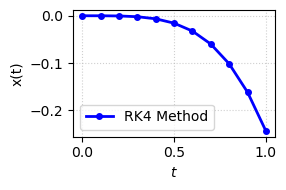

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, t):
    return x ** 2 - t ** 3

h = 0.1
t0, tend = 0, 1
x0 = 0
N = int((tend-t0)/h)
x = np.zeros(N+1)
t = np.zeros(N+1)
t[0]=t0
x[0]=x0

for i in range(N):
    t[i+1] = t[i] + h
    k1 = h * f(x[i], t[i])
    k2 = h * f(x[i]+0.5*k1, t[i]+0.5*h)
    k3 = h * f(x[i]+0.5*k2, t[i]+0.5*h)
    k4 = h * f(x[i]+k3, t[i]+h)
    x[i+1] = x[i] + (1/6) * (k1 + 2*k2 + 2*k3 + k4)

plt.figure(figsize=(3, 2))
plt.plot(t, x, 'bo-', label="RK4 Method", linewidth=2, markersize=4)
plt.xlabel("$t$")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Differential Equations: Several Variables

## Multivariable Euler Method

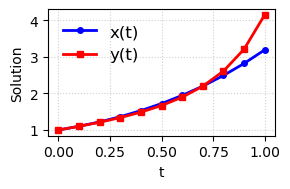

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define f(r, t) ---
def f(r, t):
    x, y = r
    dxdt = x + t
    dydt = y**2 - t
    return np.array([dxdt, dydt])

# --- Parameters ---
h, t0, tend = 0.1, 0.0, 1.0
N = int((tend - t0) / h)

# --- Initial Conditions ---
x0, y0 = 1.0, 1.0

# --- Pre-allocate Arrays ---
t = np.zeros(N + 1)
r = np.zeros((N + 1, 2))   # each row is [x, y]

t[0]    = t0
r[0, :] = [x0, y0]

# --- Euler Method ---
for i in range(N):
    t[i+1]    = t[i] + h
    r[i+1, :] = r[i, :] + h * f(r[i, :], t[i])   

# --- Extract Components ---
x = r[:, 0]
y = r[:, 1]

# --- Plot ---
plt.figure(figsize=(3, 2))
plt.plot(t, x, 'bo-', label="x(t)",  linewidth=2, markersize=4)
plt.plot(t, y, 'rs-', label="y(t)",  linewidth=2, markersize=4)
plt.xlabel("t")
plt.ylabel("Solution")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, alpha=0.6, ls=':')
plt.tight_layout()
plt.show()

## Multivariable RK4

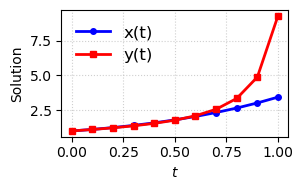

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define f(r, t) ---
def f(r, t):
    x, y = r
    dxdt = x + t
    dydt = y**2 - t
    return np.array([dxdt, dydt])

# --- Parameters ---
h    = 0.1
t0   = 0.0
tend = 1.0
N    = int((tend - t0) / h)

# --- Initial Conditions ---
x0 = 1.0
y0 = 1.0

# --- Pre-allocate Arrays ---
t = np.zeros(N + 1)
r = np.zeros((N + 1, 2))   # each row is [x, y]

t[0]    = t0
r[0, :] = [x0, y0]

# --- RK4 Method ---
for i in range(N):
    k1 = h * f(r[i, :], t[i])
    k2 = h * f(r[i, :] + 0.5 * k1, t[i] + 0.5 * h)
    k3 = h * f(r[i, :] + 0.5 * k2, t[i] + 0.5 * h)
    k4 = h * f(r[i, :] + k3, t[i] + h)

    t[i+1]    = t[i] + h
    r[i+1, :] = r[i, :] + (1/6) * (k1 + 2*k2 + 2*k3 + k4)   # RK4 update

# --- Extract Components ---
x = r[:, 0]
y = r[:, 1]

# --- Plot ---
plt.figure(figsize=(3, 2))
plt.plot(t, x, 'bo-', label="x(t)", linewidth=2, markersize=4)
plt.plot(t, y, 'rs-', label="y(t)", linewidth=2, markersize=4)
plt.xlabel("$t$")
plt.ylabel("Solution")
plt.legend(frameon=False, fontsize=12)
plt.grid(True, alpha=0.6, ls=':')
plt.tight_layout()
plt.show()

# 2nd-Order Differential Equations

# Other Methods

## Leapfrog Method

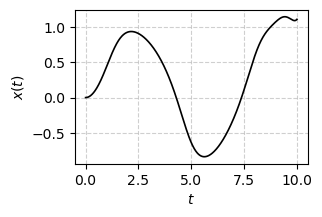

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def leapfrog(f, x0, t_start, t_end, h):
   
    # Create the array of integer time points
    t_points = np.arange(t_start, t_end + h, h)
    N = len(t_points)
    
    # Initialize the array for the calculated x values
    x_points = np.zeros(N)
    x_points[0] = x0
    
    # Setup phase
    t_mid = t_start + 0.5 * h
    x_mid = x0 + 0.5 * h * f(x0, t_start)
    
    x_points[1] = x0 + h * f(x_mid, t_mid)
    
    for i in range(1, N - 1):
        # Advance the midpoint by using the slope at the current integer point
        x_mid = x_mid + h * f(x_points[i], t_points[i])
        t_mid = t_mid + h
        
        # Advance the integer point by using the slope at the new midpoint
        x_points[i+1] = x_points[i] + h * f(x_mid, t_mid)
        
    return t_points, x_points

    # Define the specific differential equation
def f(x, t):
    return -x**3 + np.sin(t)

# Set the parameters
x0 = 0.0
t_start = 0.0
t_end = 10.0
h = 0.01  # Step size

# Run the leapfrog algorithm
t_vals, x_vals = leapfrog(f, x0, t_start, t_end, h)

# Plot 
plt.figure(figsize=(3, 2))
plt.plot(t_vals, x_vals, color="k", linewidth=1.2)
plt.xlabel("$t$")
plt.ylabel("$x(t)$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Verlet Method

In [1]:
import numpy as np

def verlet(f, x0, v0, t_start, t_end, h):

    # Create the array of integer time points
    t_points = np.arange(t_start, t_end + h, h)
    N = len(t_points)
    
    # Initialize the arrays for position and synchronized velocity
    x_points = np.zeros(N)
    v_points = np.zeros(N)
    
    x_points[0] = x0
    v_points[0] = v0
    
    # Step 1: The Initial Setup (First half-step for velocity)
    v_mid = v0 + 0.5 * h * f(x0, t_start)
    
    # Step 2: The Main Verlet Loop
    for i in range(N - 1):
        # 1. Update Position
        x_points[i+1] = x_points[i] + h * v_mid
        
        # 2. Calculate Force/Slope Parameter at the new position
        k = h * f(x_points[i+1], t_points[i+1])
        
        # 3. Synchronize Velocity (at the integer step)
        v_points[i+1] = v_mid + 0.5 * k
        
        # 4. Update Staggered Velocity (for the next loop iteration)
        v_mid = v_mid + k
        
    return t_points, x_points, v_points

# Define the acceleration function for a simple harmonic oscillator: d^2x/dt^2 = -x
def f(x, t):
    return -x

# Set parameters (Starting pulled back to x=1, released from rest)
initial_position = 1.0
initial_velocity = 0.0
start_time = 0.0
end_time = 5.0
step_size = 0.1

# Run the algorithm
t_vals, x_vals, v_vals = verlet(f, initial_position, initial_velocity, start_time, end_time, step_size)

# Print the first few results
print("First 5 steps:")
for t, x, v in zip(t_vals[:5], x_vals[:5], v_vals[:5]):
    print(f"t = {t:.1f}, x = {x:.4f}, v = {v:.4f}")

First 5 steps:
t = 0.0, x = 1.0000, v = 0.0000
t = 0.1, x = 0.9950, v = -0.0998
t = 0.2, x = 0.9800, v = -0.1985
t = 0.3, x = 0.9553, v = -0.2953
t = 0.4, x = 0.9210, v = -0.3891
